## Data Load

In [8]:
import pandas as pd

file_dir = "C:/Users/qkrru/Downloads/HDelevator/elevator_fault_dataset_full.csv"

df = pd.read_csv(file_dir)

df.head()

,Timestamp,Motor_Current,Motor_Voltage,Vibration_Level,Speed,Cabin_Position,Cabin_Acceleration,Cabin_Deceleration,Door_Operation_Time,Braking_Force,...,Control_System_Delay,Frequency_of_Emergency_Stops,Button_Press_Logs,Door_Obstruction_Events,Overload_Events,Health_Indices,RUL,Fault_State,Fault_Category,Fault_Severity
0,2020-01-01 00:00:00,22.289903,241.253222,1.393233,3.519079,19,0.349191,0.358643,5.747832,112.280046,...,0.097096,3,61.037683,0,0,171.975594,893.941155,1,Door Failure,Minor
1,2020-01-01 01:00:00,25.240487,236.078046,0.090303,2.226921,9,0.260127,0.266565,7.552277,142.770141,...,0.075588,1,15.653676,0,0,150.250886,2130.455491,0,Brake Failure,Critical
2,2020-01-01 02:00:00,32.769471,432.220975,0.932987,2.523211,20,0.291057,0.161099,7.703547,98.016876,...,0.091237,3,25.963784,0,0,164.327588,2472.445475,0,Motor Malfunction,Minor
3,2020-01-01 03:00:00,34.913962,645.108627,0.490413,4.910428,20,0.439094,0.214058,8.335525,75.588623,...,0.128085,2,25.590539,0,0,142.256458,1753.632090,0,Motor Malfunction,Moderate
4,2020-01-01 04:00:00,27.799073,224.451891,0.844176,5.188226,20,0.566116,0.365294,4.717031,95.882924,...,0.112181,2,41.910883,0,0,89.765157,2399.361778,0,Sensor Error,Critical


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43081 entries, 0 to 43080
Data columns (total 46 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     43081 non-null  object 
 1   Motor_Current                 43081 non-null  float64
 2   Motor_Voltage                 43081 non-null  float64
 3   Vibration_Level               43081 non-null  float64
 4   Speed                         43081 non-null  float64
 5   Cabin_Position                43081 non-null  int64  
 6   Cabin_Acceleration            43081 non-null  float64
 7   Cabin_Deceleration            43081 non-null  float64
 8   Door_Operation_Time           43081 non-null  float64
 9   Braking_Force                 43081 non-null  float64
 10  Rope_Tension                  43081 non-null  float64
 11  Guide_Rail_Condition_Index    43081 non-null  float64
 12  Pulley_Wear                   43081 non-null  float64
 13  L

## Elevator Fault DeepLearning Model
- TAFN(Temporal Adaptive Fault Network)
    : 이진, 다중 클래스 분류 작업
- GNN-LSTM-BDANN
    : 엘리베이터 도어 시스템 고장 예측
- VMD-BILSTM-AEAM
    : 엘리베이터 고장 전조 예측
- CNN-LSTM
    : 잔여 유효 수명(RUL) 예측

### lstm_attention fault forecasting

In [45]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Attention, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# 1. 데이터 로드
# -----------------------------
df = pd.read_csv(file_dir, encoding='cp949')

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp')

# -----------------------------
# 2. 편차 및 rolling 적용
# -----------------------------
df['vibration_diff'] = df['Vibration_Level'].diff()
df['current_diff'] = df['Motor_Current'].diff()

df['vibration_std_10'] = df['Vibration_Level'].rolling(10).std()
df['current_std_10'] = df['Motor_Current'].rolling(10).std()

# -----------------------------
# 3. window 적용
# -----------------------------
WINDOW = 15

df['Fault_future'] = (
    df['Fault_State']
    .rolling(window=WINDOW)
    .max()
    .shift(-WINDOW)
)

df = df.dropna()

# -----------------------------
# 4. Feature 및 Target 선택
# -----------------------------
features = [
    'Motor_Current',
    'Vibration_Level',
    'Speed',
    'Cabin_Acceleration',
    'Braking_Force',
    'vibration_diff',
    'current_diff',
    'vibration_std_10',
    'current_std_10'
]

X = df[features]
y = df['Fault_future']

# -----------------------------
# 5. 스케일링
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 6. Sequence 생성
# -----------------------------
def create_sequences(X, y, seq_len=30):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y.iloc[i+seq_len])
    return np.array(Xs), np.array(ys)

SEQ_LEN = 30
X_seq, y_seq = create_sequences(X_scaled, y, SEQ_LEN)

# -----------------------------
# 7. Train/Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

# -----------------------------
# 8. 클래스 가중치 적용 -> 고장에 5배 더
# -----------------------------
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1] * 5
}

# -----------------------------
# 9. TAFN 모델
# -----------------------------
inputs = Input(shape=(SEQ_LEN, X_seq.shape[2]))

lstm_out = LSTM(64, return_sequences=True)(inputs)

attention = Attention()([lstm_out, lstm_out])
context = GlobalAveragePooling1D()(attention)

dense = Dense(32, activation='relu')(context)
outputs = Dense(1, activation='sigmoid')(dense)

model = Model(inputs, outputs)

def focal_loss(gamma=2., alpha=0.7):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        pt = tf.exp(-bce)
        return alpha * (1 - pt)**gamma * bce
    return loss

model.compile(
    optimizer='adam',
    loss=focal_loss(),
    metrics=['accuracy']
)

# -----------------------------
# 10. 학습
# -----------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------
# 11. 예측
# -----------------------------
y_prob = model.predict(X_test).ravel()

# threshold 튜닝
best_f1 = 0
best_t = 0

for t in np.linspace(0.05, 0.5, 20):
    pred = (y_prob > t).astype(int)
    score = f1_score(y_test, pred)
    if score > best_f1:
        best_f1 = score
        best_t = t

print("Best Threshold:", best_t)

y_pred = (y_prob > best_t).astype(int)

# -----------------------------
# 12. 평가
# -----------------------------
print("F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.5249 - loss: 0.2548 - val_accuracy: 0.5396 - val_loss: 0.1589
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.5255 - loss: 0.2464 - val_accuracy: 0.5396 - val_loss: 0.1562
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.5255 - loss: 0.2454 - val_accuracy: 0.5396 - val_loss: 0.1557
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.5255 - loss: 0.2437 - val_accuracy: 0.5396 - val_loss: 0.1576
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.5255 - loss: 0.2418 - val_accuracy: 0.5396 - val_loss: 0.1524
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.5255 - loss: 0.2382 - val_accuracy: 0.5396 - val_loss: 0.1522
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.5275 - loss: 0.2328 - val_accuracy: 0.5420 - val_loss: 0.1480
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.5363 - loss: 0.2243 - 

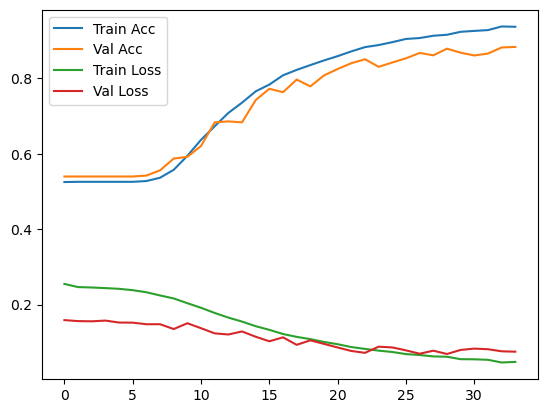

In [48]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.legend()
plt.show()

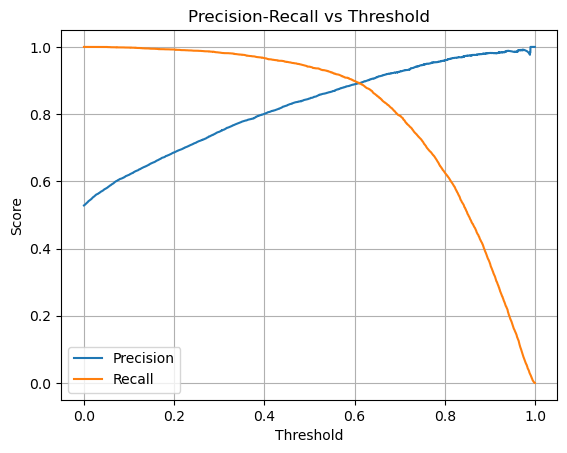

In [49]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid()
plt.show()

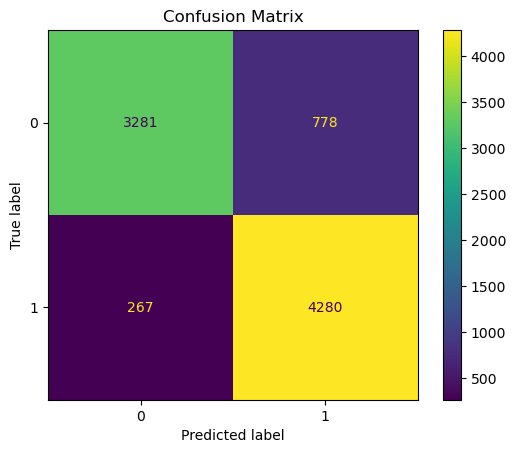

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

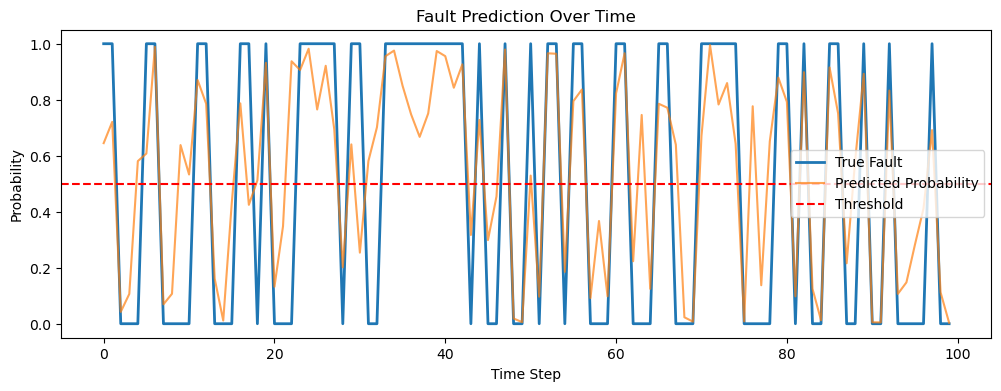

In [51]:
plt.figure(figsize=(12,4))

# 일부 구간만 보기
idx = range(0, 100)

plt.plot(y_test[idx], label='True Fault', linewidth=2)
plt.plot(y_prob[idx], label='Predicted Probability', alpha=0.7)

plt.axhline(y=best_t, color='r', linestyle='--', label='Threshold')

plt.legend()
plt.title("Fault Prediction Over Time")
plt.xlabel("Time Step")
plt.ylabel("Probability")
plt.show()

In [25]:
print(df[['Fault_State', 'Fault_future']].corr())

              Fault_State  Fault_future
Fault_State      1.000000      0.001662
Fault_future     0.001662      1.000000


In [26]:
WINDOW = [10, 20, 30, 50]

for w in WINDOW:
    df['Fault_future'] = (
        df['Fault_State']
        .rolling(w)
        .max()
        .shift(-w)
    )
    print(w, df['Fault_future'].mean())

10 0.39765810138934066
20 0.6318321249302844
30 0.7755102040816326
50 0.9193758429840473


In [27]:
df['fault_group'] = (df['Fault_State'] != df['Fault_State'].shift()).cumsum()

fault_lengths = df[df['Fault_State'] == 1].groupby('fault_group').size()

print(fault_lengths.describe())

count    2022.000000
mean        1.043521
std         0.213556
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
dtype: float64
